## ANN - Búsqueda IVF

Se buscan los `K` vecinos más parecidos de una muestra de consultas con el índice IVF y se compara contra la fuerza bruta

- Consulta → sus `NPROBE` listas → candidatos de la misma **categoría** en esas listas → coseno nativo → top-K

- Nunca se compara contra todo el índice

- Experimentos: listas revisadas por consulta (`NPROBE`) y número de listas del índice (`NLIST`)

### Imports

In [1]:
import os, socket, time, shutil, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
vectores_dir = proyecto / "03_ANN" / "temp" / "a_tfidf" / "vectores"
centroides_dir = proyecto / "03_ANN" / "temp" / "b_ind_ivf" / "centroides"
listas_dir = proyecto / "03_ANN" / "temp" / "b_ind_ivf" / "listas"
out_dir = proyecto / "03_ANN" / "temp" / "c_bus_ivf"
out_dir.mkdir(parents=True, exist_ok=True)
consultas_dir = out_dir / "consultas"
vecinos_dir = out_dir / "vecinos"
lotes_dir = out_dir / "vecinos_lotes"
eval_dir = out_dir / "eval"

- Funciones

Parámetros y funciones compartidas de `03_ANN/funciones.ipynb`

In [3]:
ruta_funciones = str(proyecto / "03_ANN" / "funciones.ipynb")
%run $ruta_funciones

- Figuras y tablas

In [4]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()


def guardar_tabla(df, nombre):
    # parquet para el siguiente notebook + json para la página web
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()


def dirs_salida(out_dir):
    fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
    for d in (fig_dir, tab_dir, web_dir):
        d.mkdir(parents=True, exist_ok=True)
    return fig_dir, tab_dir, web_dir


fig_dir, tab_dir, web_dir = dirs_salida(out_dir)

- Spark

In [5]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("ann-busqueda")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))     # 4g (vs 2g en 05): firmas/vectores y joins por pares pesan más que canastas
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")                                   # ~231k filas: 24 tareas bastan, las 200 por defecto quedarían casi vacías
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")                           # sin broadcast automático: los parquets descomprimidos saturaban el driver
           .config("spark.sql.optimizer.canChangeCachedPlanOutputPartitioning", "false")   # bug de joins con caché en Spark 3.5.0
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [ ]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

---
### 1. Carga e índice

In [7]:
assert listas_dir.exists(), f"No se encuentra {listas_dir}; corre b_ind_ivf.ipynb"
vectores = spark.read.parquet(str(vectores_dir)).drop("vec", "tokens")
listas   = spark.read.parquet(str(listas_dir))
N = vectores.count()

indice = (vectores.join(listas.select("ocid", "lista"), "ocid")
                  .select("ocid", "categoria", "lista", "entidad", "region", "monto_final", "idx", "val").cache())
print(f"Índice: {indice.count():,} vectores en {NLIST} listas")

Índice: 235,954 vectores en 300 listas


### 2. Consultas

La muestra se escribe en `temp/c_bus_ivf/consultas` y se relee: así es siempre la misma aunque Spark tenga que recalcular algo

In [8]:
if not consultas_dir.exists():
    (vectores.join(listas.select("ocid", "listas_probe"), "ocid")
             .sample(fraction=min(1.0, N_QUERIES / N), seed=SEED)
             .select("ocid", "categoria", "listas_probe", "entidad", "region", "monto_final", "idx", "val")
             .write.mode("overwrite").parquet(str(consultas_dir)))
consultas = spark.read.parquet(str(consultas_dir)).cache()
n_q = consultas.count()
print(f"Consultas: {n_q:,} | listas revisadas por consulta: {NPROBE}")

Consultas: 20,062 | listas revisadas por consulta: 2


### 3. Búsqueda IVF por lotes

- Las consultas se procesan en lotes de `TAM_LOTE`; cada lote es chico y se envía a todos los workers (broadcast explícito), así el índice no se mueve

- Al join solo viajan `ocid` + vector; entidad, región y monto se pegan después del top-K

- Los candidatos no se guardan en memoria: se cuentan con el tamaño de las listas

- Reanudable: salta los lotes ya escritos. Para rehacer todo, `REINICIAR = True`

- Auxiliar

In [9]:
idx_v = indice.select(F.col("ocid").alias("ocid_v"), "lista", "categoria", F.col("idx").alias("idx_v"), F.col("val").alias("val_v"))
meta  = indice.select("ocid", "entidad", "region", "monto_final")
meta_q = meta.select(*[F.col(c).alias(f"{c}_q") for c in meta.columns])
meta_v = meta.select(*[F.col(c).alias(f"{c}_v") for c in meta.columns])
tam_listas = indice.groupBy("lista", "categoria").count()

def buscar_ivf(cons, indice_v=None):
    # consulta -> sus NPROBE listas -> vectores de esas listas (misma categoría) -> coseno
    # indice_v permite probar otro índice (experimento de NLIST); por defecto, el de b_ind_ivf
    iv = idx_v if indice_v is None else indice_v
    q = cons.select(F.col("ocid").alias("ocid_q"), "categoria", F.explode("listas_probe").alias("lista"),
                    F.col("idx").alias("idx_q"), F.col("val").alias("val_q"))
    return (iv.join(F.broadcast(q), ["lista", "categoria"]).where("ocid_q != ocid_v")
                 .select("ocid_q", "ocid_v", "categoria", coseno("idx_q", "val_q", "idx_v", "val_v").alias("cos_sim")))

def completar(top):
    return (top.join(meta_q, "ocid_q").join(meta_v, "ocid_v")
               .withColumn("cos_sim", F.round("cos_sim", 4))
               .withColumn("misma_entidad", F.col("entidad_q") == F.col("entidad_v"))
               .withColumn("misma_region", F.col("region_q") == F.col("region_v")))

- Flujo

In [10]:
spark.conf.set("spark.sql.optimizer.windowGroupLimitThreshold", "-1")   # top-K sin atajos de Spark 3.5.0

TAM_LOTE = 2000            # ~10 lotes; 2,000 consultas x NPROBE listas caben en un broadcast. Bajar a 1000 o 500 si falta memoria
REINICIAR = True           # True borra temp/c_bus_ivf/vecinos y empieza de cero; False reanuda los lotes ya escritos

n_lotes = max(1, math.ceil(n_q / TAM_LOTE))
# lote = hash del ocid mod n_lotes: reparto uniforme y determinista (cada consulta cae siempre en el mismo lote y se puede reanudar)
consultas_l = consultas.withColumn("lote", F.pmod(F.xxhash64("ocid"), F.lit(n_lotes)).cast("int")).cache()

if REINICIAR:
    for d_ in [vecinos_dir, lotes_dir]:
        if d_.exists(): shutil.rmtree(d_)
hechos = {int(p_.name.split("=")[1]) for p_ in vecinos_dir.glob("lote=*")} if vecinos_dir.exists() else set()
print(f"{n_q:,} consultas en {n_lotes} lotes | ya hechos: {len(hechos)}")

t_total = time.time()
for l in range(n_lotes):
    if l in hechos:
        continue
    t0 = time.time()
    lote_q = consultas_l.where(F.col("lote") == l)
    n_lq = lote_q.count()
    n_c = (lote_q.select("categoria", F.explode("listas_probe").alias("lista"))
                 .join(tam_listas, ["lista", "categoria"]).agg(F.sum("count")).first()[0] or 0) - n_lq
    completar(top_k(buscar_ivf(lote_q))).withColumn("lote", F.lit(l)).write.mode("append").partitionBy("lote").parquet(str(vecinos_dir))
    spark.createDataFrame([(l, n_c)], "lote int, candidatos long").write.mode("append").parquet(str(lotes_dir))
    print(f"lote {l + 1:3d}/{n_lotes}: {n_c:12,} candidatos  ({time.time() - t0:6.1f} s)")
print(f"Total: {time.time() - t_total:,.0f} s")

vecinos = spark.read.parquet(str(vecinos_dir)).cache()
n_vec = vecinos.count()
n_cand = spark.read.parquet(str(lotes_dir)).agg(F.sum("candidatos")).first()[0]
print(f"IVF: {n_cand:,} candidatos evaluados → {n_vec:,} vecinos ({n_vec / n_q:.1f} por consulta)")
print(f"Comparaciones evitadas vs. fuerza bruta: {1 - n_cand / (n_q * N):.1%}")

20,062 consultas en 11 lotes | ya hechos: 0


lote   1/11:   11,737,326 candidatos  (  26.2 s)


lote   2/11:   11,344,142 candidatos  (  24.0 s)


lote   3/11:   11,907,694 candidatos  (  23.9 s)


lote   4/11:   12,072,851 candidatos  (  24.0 s)


...

lote   8/11:   11,424,484 candidatos  (  22.2 s)


lote   9/11:   11,598,367 candidatos  (  23.3 s)


lote  10/11:   11,173,804 candidatos  (  22.2 s)


lote  11/11:   11,420,630 candidatos  (  22.5 s)
Total: 258 s


IVF: 127,314,108 candidatos evaluados → 200,614 vecinos (10.0 por consulta)
Comparaciones evitadas vs. fuerza bruta: 97.3%


#### a. Verificación

Cada consulta con sus `K` vecinos, cosenos en [0, 1] y ninguna con más de `K`

In [11]:
por_q = vecinos.groupBy("ocid_q").count()
n_con = por_q.count(); n_completas = por_q.where(f"count = {K}").count()
print(f"Consultas con vecinos: {n_con:,} de {n_q:,} | con {K} vecinos completos: {n_completas:,} ({n_completas / n_q:.1%})")
# tolerancia de 90%: una consulta en una lista muy chica de su categoría puede quedar con < K vecinos
assert n_completas / n_q > 0.90, "Faltan vecinos: poner REINICIAR = True en la sección 3 y volver a correr"
assert vecinos.where((F.col("cos_sim") < -1e-6) | (F.col("cos_sim") > 1 + 1e-6)).count() == 0
assert vecinos.groupBy("ocid_q").count().where(f"count > {K}").count() == 0
vecinos.printSchema()
(vecinos.where("rank = 1").orderBy(F.desc("cos_sim"))
        .select("entidad_q", "entidad_v", "region_q", "region_v", "cos_sim", "monto_final_q", "monto_final_v").show(8, truncate=30))

Consultas con vecinos: 20,062 de 20,062 | con 10 vecinos completos: 20,060 (100.0%)


root
 |-- ocid_v: string (nullable = true)
 |-- ocid_q: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- cos_sim: double (nullable = true)
 |-- rank: integer (nullable = true)
 |-- entidad_q: string (nullable = true)
 |-- region_q: string (nullable = true)
 |-- monto_final_q: double (nullable = true)
 |-- entidad_v: string (nullable = true)
 |-- region_v: string (nullable = true)
 |-- monto_final_v: double (nullable = true)
 |-- misma_entidad: boolean (nullable = true)
 |-- misma_region: boolean (nullable = true)
 |-- lote: integer (nullable = true)



+------------------------------+------------------------------+------------+------------+-------+-------------+-------------+
|                     entidad_q|                     entidad_v|    region_q|    region_v|cos_sim|monto_final_q|monto_final_v|
+------------------------------+------------------------------+------------+------------+-------+-------------+-------------+
|MTC-PROYECTO ESPECIAL DE IN...|MTC-PROYECTO ESPECIAL DE IN...|        LIMA|        LIMA|    1.0|      80000.0|      70000.0|
|MINISTERIO PUBLICO - GERENC...|MINISTERIO PUBLICO - GERENC...|    AREQUIPA|    AREQUIPA|    1.0|   1093306.95|   2398960.84|
|GOBIERNO REGIONAL DE HUANCA...|GOBIERNO REGIONAL DE HUANCA...|HUANCAVELICA|HUANCAVELICA|    1.0|     162150.0|     162150.0|
|INSTITUTO NACIONAL DE OFTAL...|INSTITUTO NACIONAL DE OFTAL...|        LIMA|        LIMA|    1.0|      68600.0|         NULL|
|MUNICIPALIDAD PROVINCIAL DE...|MUNICIPALIDAD PROVINCIAL DE...|  HUAROCHIRI|  HUAROCHIRI|    1.0|   9960199.72|   9960

### 4. Fuerza bruta: recall@K y tiempo

- Las mismas `N_EXACT` consultas se comparan contra **todos** los vectores de su categoría, en lotes chicos de `TAM_LOTE_EXACTO`

- recall@K = fracción de los K vecinos exactos que IVF también encontró

In [12]:
TAM_LOTE_EXACTO = 25       # cada consulta se compara con toda su categoría (hasta ~104k vectores): 25 consultas ≈ 2.6 M cosenos por lote
tmp_dir = eval_dir
if tmp_dir.exists():
    shutil.rmtree(tmp_dir)

cons_e = consultas.sample(fraction=min(1.0, N_EXACT / n_q), seed=SEED)
n_lotes_e = max(1, math.ceil(N_EXACT / TAM_LOTE_EXACTO))
cons_e = cons_e.withColumn("lote", F.pmod(F.xxhash64("ocid"), F.lit(n_lotes_e)).cast("int")).cache()
n_e = cons_e.count()
todos_v = indice.select(F.col("ocid").alias("ocid_v"), "categoria", F.col("idx").alias("idx_v"), F.col("val").alias("val_v"))

t0 = time.time()
for l in range(n_lotes_e):
    q = cons_e.where(F.col("lote") == l).select(F.col("ocid").alias("ocid_q"), "categoria", F.col("idx").alias("idx_q"), F.col("val").alias("val_q"))
    parte = (todos_v.join(F.broadcast(q), "categoria").where("ocid_q != ocid_v")
                    .select("ocid_q", "ocid_v", coseno("idx_q", "val_q", "idx_v", "val_v").alias("cos_sim")))
    top_k(parte).select("ocid_q", "ocid_v", "cos_sim").write.mode("append").parquet(str(tmp_dir / "exacto"))
t_exacto = time.time() - t0

t0 = time.time()
top_k(buscar_ivf(cons_e)).select("ocid_q", "ocid_v", "cos_sim").write.mode("overwrite").parquet(str(tmp_dir / "ivf"))
t_ivf_e = time.time() - t0

exacto = spark.read.parquet(str(tmp_dir / "exacto")).cache()
ivf_e  = spark.read.parquet(str(tmp_dir / "ivf")).cache()
n_ex = exacto.count()
aciertos = exacto.join(ivf_e, ["ocid_q", "ocid_v"]).count()
recall = aciertos / n_ex
print(f"{n_e} consultas | fuerza bruta: {t_exacto:,.1f} s | IVF: {t_ivf_e:,.1f} s ({t_exacto / max(t_ivf_e, 1e-9):.1f}x más rápido)")
print(f"recall@{K} = {aciertos:,} / {n_ex:,} = {recall:.1%}")

340 consultas | fuerza bruta: 63.2 s | IVF: 4.3 s (14.8x más rápido)
recall@10 = 2,550 / 3,400 = 75.0%


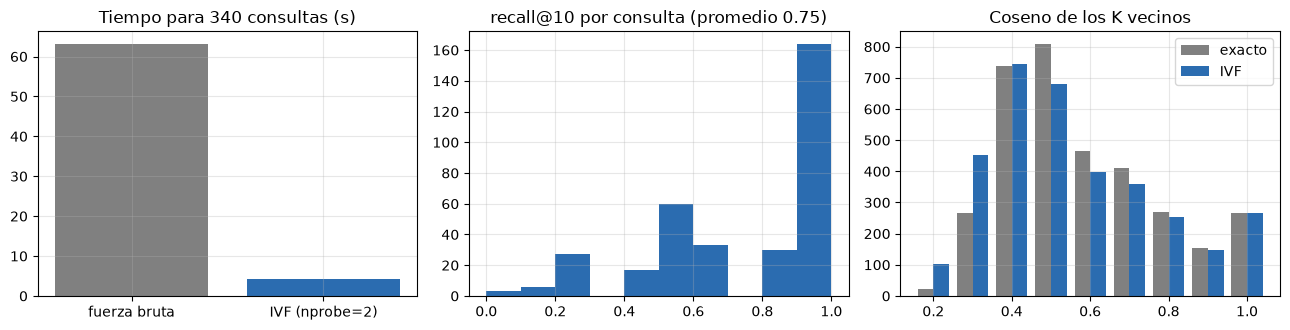

In [13]:
r_q = (exacto.join(ivf_e.select("ocid_q", "ocid_v", F.lit(1).alias("hit")), ["ocid_q", "ocid_v"], "left")
             .groupBy("ocid_q").agg((F.sum(F.coalesce("hit", F.lit(0))) / F.count("*")).alias("recall")).toPandas())
dist_ex = exacto.where("cos_sim >= 0").select(F.round("cos_sim", 1).alias("c")).groupBy("c").count().orderBy("c").toPandas()
dist_iv = ivf_e.where("cos_sim >= 0").select(F.round("cos_sim", 1).alias("c")).groupBy("c").count().orderBy("c").toPandas()

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].bar(["fuerza bruta", f"IVF (nprobe={NPROBE})"], [t_exacto, t_ivf_e], color=["gray", "#2b6cb0"]); ax[0].set_title(f"Tiempo para {n_e} consultas (s)")
ax[1].hist(r_q["recall"], bins=np.linspace(0, 1, 11), color="#2b6cb0"); ax[1].set_title(f"recall@{K} por consulta (promedio {recall:.2f})")
ax[2].bar(dist_ex["c"] - .02, dist_ex["count"], width=.04, color="gray", label="exacto"); ax[2].bar(dist_iv["c"] + .02, dist_iv["count"], width=.04, color="#2b6cb0", label="IVF")
ax[2].set_title("Coseno de los K vecinos"); ax[2].legend(); mostrar_fig("ivf_vs_fuerza_bruta")

- 20,062 consultas en 11 lotes (258 s), con sus 10 vecinos (20,060 completas), evitando el 97.3% de las comparaciones

- En 340 consultas, IVF es 14.8x más rápido que la fuerza bruta (4.3 s vs 63.2 s) con recall@10 = 75%

- IVF revisa solo `NPROBE / NLIST` de las listas y pierde los vecinos que cayeron en listas no visitadas: ese es el costo en recall

### 5. Experimento: listas revisadas por consulta (`NPROBE`)

- Mismo índice y mismas consultas de la fuerza bruta; solo cambia cuántas listas se revisan: 1, 2 y 4

- Se mide recall@K contra los vecinos exactos de la sección 4, tiempo y fracción del índice revisada

- Auxiliar

In [14]:
centroides = np.array([r_["centroide"] for r_ in spark.read.parquet(str(centroides_dir)).orderBy("lista").collect()])
centroides_bc = sc.broadcast(centroides)

def evaluar_ivf(cons, indice_v=None):
    # top-K con IVF para las consultas de la fuerza bruta → recall@K, segundos de búsqueda y candidatos revisados
    t0 = time.time()
    res = top_k(buscar_ivf(cons, indice_v)).select("ocid_q", "ocid_v").cache()
    res.count()
    seg = time.time() - t0
    rec = exacto.join(res, ["ocid_q", "ocid_v"]).count() / n_ex
    n_c = buscar_ivf(cons, indice_v).count()
    res.unpersist()
    return rec, seg, n_c

- Flujo

In [15]:
EXP_NPROBE = [1, 2, 4]     # la mitad, el actual y el doble de listas por consulta
filas = []
for p_ in EXP_NPROBE:
    cons_p = cons_e.withColumn("listas_probe", asignar_listas_udf(centroides_bc, p_)("idx", "val"))
    rec, seg, n_c = evaluar_ivf(cons_p)
    filas.append({"NPROBE": p_, "recall@K": round(rec, 3), "seg": round(seg, 1), "candidatos": n_c,
                  "frac_indice_revisado": round(n_c / (n_e * N), 4)})
tabla_np = pd.DataFrame(filas)
print(f"Fuerza bruta: {t_exacto:,.1f} s para {n_e} consultas")
tabla_np

Fuerza bruta: 63.2 s para 340 consultas


,NPROBE,recall@K,seg,candidatos,frac_indice_revisado
0,1,0.638,2.9,844549,0.0105
1,2,0.750,4.1,2140990,0.0267
2,4,0.810,7.9,4428015,0.0552


### 6. Experimento: número de listas del índice (`NLIST`)

- Se reentrena KMeans con 100, 300 y 600 listas y se reasigna todo el índice; `NPROBE` queda fijo

- Más listas = listas más chicas: menos candidatos por consulta, pero más vecinos caen en listas no revisadas

- Es el experimento más caro (3 KMeans sobre los 231k vectores, varios minutos)

In [16]:
EXP_NLIST = [100, 300, 600]   # ≈ 2,300 / 770 / 385 vectores por lista
vec_ml = spark.read.parquet(str(vectores_dir)).select("ocid", "vec", "idx", "val")
filas = []
for nl in EXP_NLIST:
    t0 = time.time()
    _, cent_nl = entrenar_centroides(vec_ml.select("ocid", "vec"), nlist=nl)
    seg_km = time.time() - t0
    bc_nl = sc.broadcast(cent_nl)
    listas_nl = vec_ml.select("ocid", asignar_listas_udf(bc_nl, NPROBE)("idx", "val").alias("listas_probe")).cache()
    idx_v_nl = (indice.select(F.col("ocid").alias("ocid_v"), "categoria", F.col("idx").alias("idx_v"), F.col("val").alias("val_v"))
                      .join(listas_nl.select(F.col("ocid").alias("ocid_v"), F.col("listas_probe")[0].alias("lista")), "ocid_v").cache())
    cons_nl = cons_e.drop("listas_probe").join(listas_nl, "ocid")
    rec, seg, n_c = evaluar_ivf(cons_nl, idx_v_nl)
    filas.append({"NLIST": nl, "seg_kmeans": round(seg_km, 1), "recall@K": round(rec, 3), "seg_busqueda": round(seg, 1),
                  "candidatos": n_c, "frac_indice_revisado": round(n_c / (n_e * N), 4)})
    listas_nl.unpersist(); idx_v_nl.unpersist(); bc_nl.unpersist()
tabla_nl = pd.DataFrame(filas)
tabla_nl

,NLIST,seg_kmeans,recall@K,seg_busqueda,candidatos,frac_indice_revisado
0,100,10.0,0.798,29.2,6776391,0.0845
1,300,40.8,0.750,14.0,2140990,0.0267
2,600,148.0,0.725,14.6,966255,0.0120


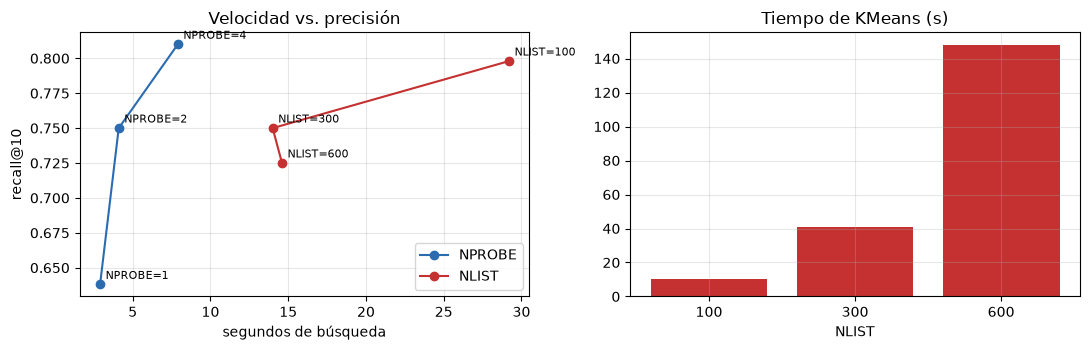

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for tabla_, col, color in [(tabla_np, "NPROBE", "#2b6cb0"), (tabla_nl, "NLIST", "#c53030")]:
    seg_col = "seg" if "seg" in tabla_ else "seg_busqueda"
    ax[0].plot(tabla_[seg_col], tabla_["recall@K"], marker="o", color=color, label=col)
    for _, f_ in tabla_.iterrows():
        ax[0].annotate(f"{col}={int(f_[col])}", (f_[seg_col], f_["recall@K"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax[0].set_xlabel("segundos de búsqueda"); ax[0].set_ylabel(f"recall@{K}"); ax[0].set_title("Velocidad vs. precisión"); ax[0].legend()
ax[1].bar(tabla_nl["NLIST"].astype(str), tabla_nl["seg_kmeans"], color="#c53030"); ax[1].set_xlabel("NLIST"); ax[1].set_title("Tiempo de KMeans (s)")
mostrar_fig("tradeoff_ivf")

- `NPROBE`: revisar 1, 2 o 4 listas da recall de 0.64, 0.75 y 0.81, con 1%, 2.7% y 5.5% del índice revisado; duplicar las listas cuesta ~2x en tiempo por +6 puntos de recall

- `NLIST`: con 100 listas el recall sube a 0.80 pero se revisa el 8.5% del índice; con 600 baja a 0.73 revisando solo el 1.2%, y el KMeans tarda 15 veces más que con 100 (148 s vs 10 s)

- Ambos mueven el mismo balance: lo que decide es la fracción del índice revisada (`NPROBE / NLIST`)

- Se mantienen `NLIST = 300` y `NPROBE = 2`: recall de 75% revisando menos del 3% del índice; para P3 alcanza, porque se buscan vecinos **muy parecidos** (coseno ≥ 0.80), los más fáciles de encontrar

### 7. Escritura de resultados

- Consultas y vecinos ya están en `temp/c_bus_ivf/consultas` y `vecinos` (insumo de `e_analisis`)

- Tablas en `temp/c_bus_ivf/tablas` (parquet) y `web/` (json)

In [18]:
resumen = pd.DataFrame([{"consultas": n_q, "K": K, "NLIST": NLIST, "NPROBE": NPROBE, "candidatos": int(n_cand),
                         "comparaciones_evitadas": round(1 - n_cand / (n_q * N), 4), "consultas_exactas": n_e,
                         "seg_fuerza_bruta": round(t_exacto, 1), "seg_ivf": round(t_ivf_e, 1), "recall_at_k": round(recall, 4)}])
tablas = {"nprobe": tabla_np, "nlist": tabla_nl, "resumen": resumen}
escritos = {nombre: guardar_tabla(df, nombre) for nombre, df in tablas.items()}
print(f"Escrito en temp/c_bus_ivf/: {', '.join(escritos)}")

Escrito en temp/c_bus_ivf/: nprobe, nlist, resumen


#### a. Verificación

In [19]:
for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 3 tablas (parquet + json) | 2 figuras: ivf_vs_fuerza_bruta, tradeoff_ivf

---
### 8. Cerrar sesión

In [20]:
spark.stop()